In [1]:
import numpy as np
from microlensing import Microlensing
from utils import ParamRange
from consts import *

In [2]:
event_url = "https://www.astrouw.edu.pl/ogle/ogle4/ews/2015/blg-0036"
ms_event = Microlensing(event_url)

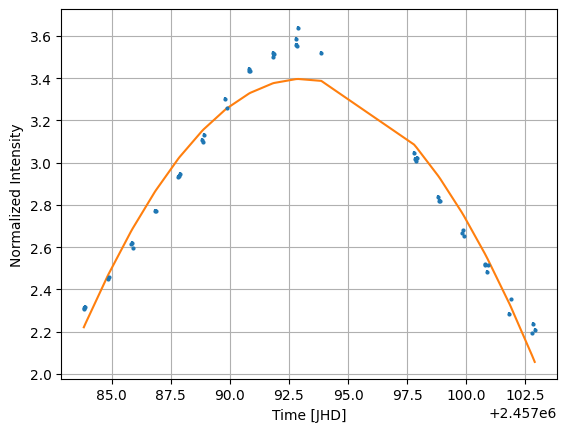

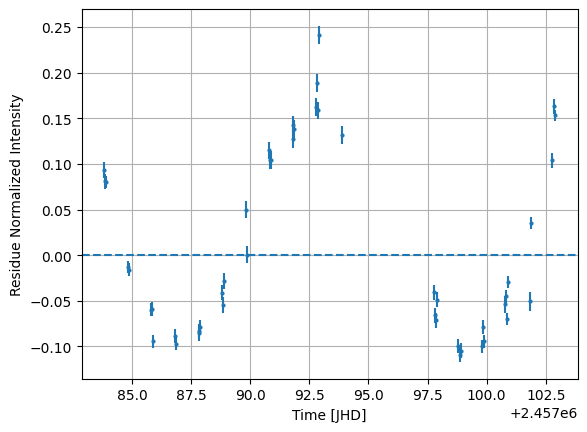

Chi: 147.98203353957481

nsigma with ogle params:
t0_ogle: 2457093.0300±0.0070
t0_par: 2457093.049±0.043
nsigma: 0.4418760857725731

Imax_ogle: 3.783±0.025
Imax_par: 3.397±0.010
nsigma: 14.26287069748591

umin_ogle: 0.2720±0.0020
umin_par: 0.2870±0.0021
nsigma: 5.136207936474258


{'t0': t0_par: 2457093.049±0.043,
 'Imax': Imax_par: 3.397±0.010,
 'umin': umin_par: 0.2870±0.0021}

In [3]:
# Apply linear parabolic fit for initial param guess
mid_range=ms_event.data["JHD"][np.argmax(ms_event.data[I_VAL])]
range_len=10
ms_event.parabolic_fit(mid_range, range_len)

In [4]:
# Use linear parabolic fit params for initial param guess

u_min_par = ms_event.par_params[U_MIN]
t0_par = ms_event.par_params[T0]
tau_ogle = ms_event.ogle[TAU]
f_bl_ogle = ms_event.ogle[F_BL]
std_range = 10

u_min_range = ParamRange(U_MIN, u_min_par.value - u_min_par.lower_error*std_range, u_min_par.value + u_min_par.upper_error*std_range)
t0_range = ParamRange(T0, t0_par.value - t0_par.lower_error*std_range, t0_par.value + t0_par.upper_error*std_range)
tau_range = ParamRange(TAU, tau_ogle.value - tau_ogle.lower_error*std_range, tau_ogle.value + tau_ogle.upper_error*std_range)
f_bl_range = ParamRange(F_BL, 0, 1.0)

params_range = [u_min_range, t0_range, tau_range, f_bl_range]
fixed_params = {}

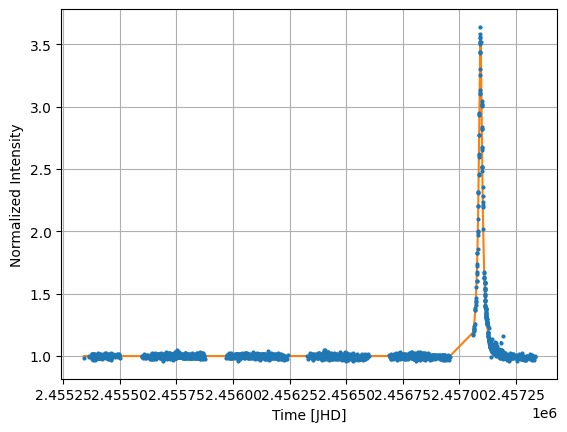

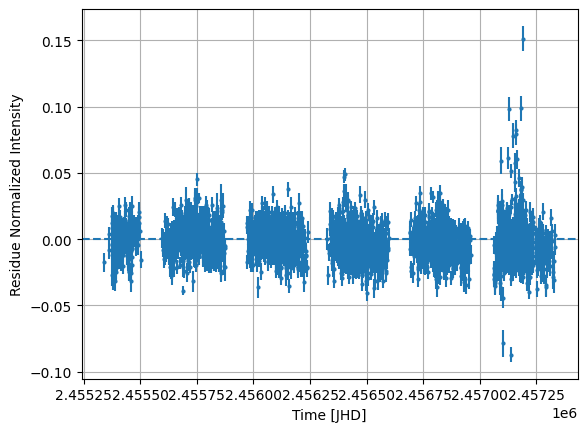

Chi: 19280.659078500343 (Chi Reduced: 4.220809780757518)

--- nsigma with ogle params ---
umin_ogle: 0.2720±0.0020
umin_non_linear_4_params: 0.265702[-0.000000,+0.000042]
nsigma: 3.1482967046191965

t0_ogle: 2457093.0300±0.0070
t0_non_linear_4_params: 2457093.0280[-0.0029,+0.0041]
nsigma: 0.24767070220116608

tau_ogle: 26.181±0.113
tau_non_linear_4_params: 26.534[-0.000,+0.011]
nsigma: 3.1200000000000037

fbl_ogle: 0.9250±0.0080
fbl_non_linear_4_params: 0.90084[-0.00052,+0.00044]
nsigma: 3.0153374666204806

--- nsigma with parabolic params ---
umin_par: 0.2870±0.0021
umin_non_linear_4_params: 0.265702[-0.000000,+0.000042]
nsigma: 9.997840415366671

t0_par: 2457093.049±0.043
t0_non_linear_4_params: 2457093.0280[-0.0029,+0.0041]
nsigma: 0.49159489665758505



{'umin': umin_non_linear_4_params: 0.265702[-0.000000,+0.000042],
 't0': t0_non_linear_4_params: 2457093.0280[-0.0029,+0.0041],
 'tau': tau_non_linear_4_params: 26.534[-0.000,+0.011],
 'fbl': fbl_non_linear_4_params: 0.90084[-0.00052,+0.00044]}

In [5]:
ms_event.non_linear_fit(params_range, fixed_params)

t0 vs. umin effect on Goodness of Fit (chi)


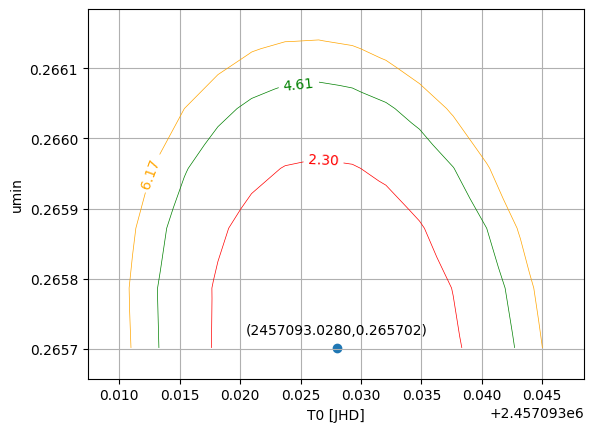

t0 vs. tau effect on Goodness of Fit (chi)


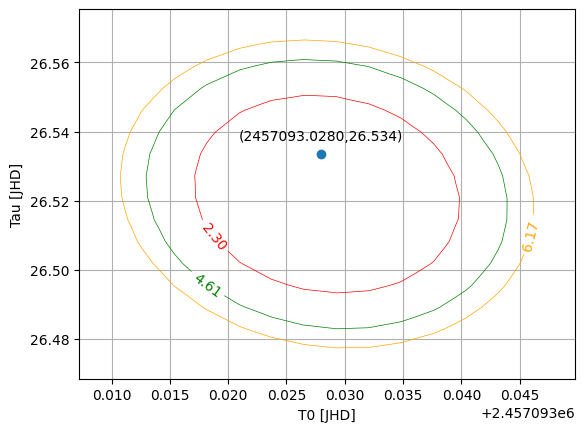

t0 vs. fbl effect on Goodness of Fit (chi)


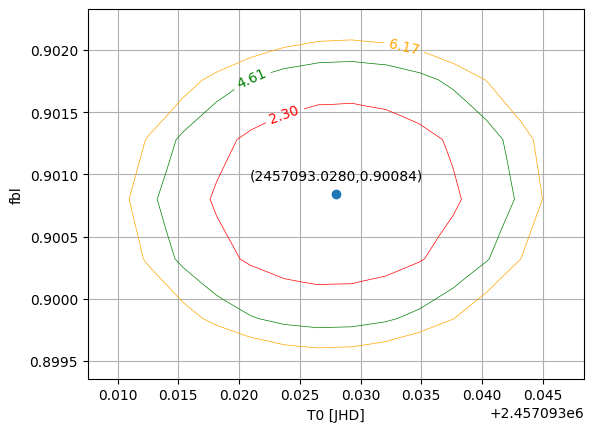

umin vs. tau effect on Goodness of Fit (chi)


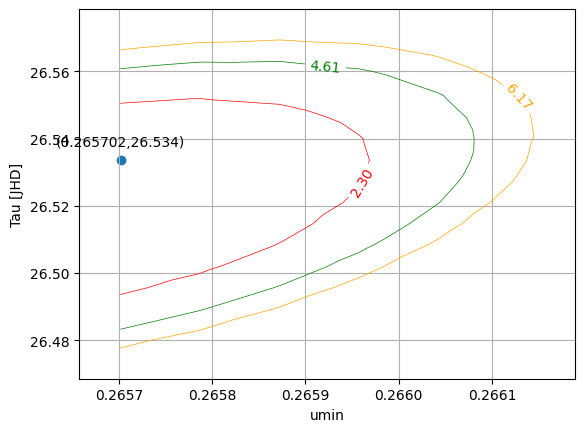

umin vs. fbl effect on Goodness of Fit (chi)


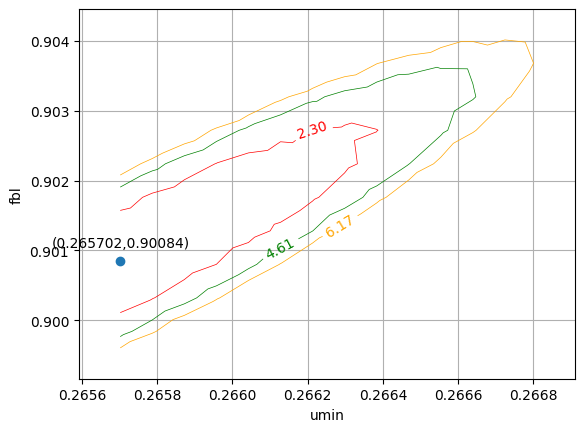

tau vs. fbl effect on Goodness of Fit (chi)


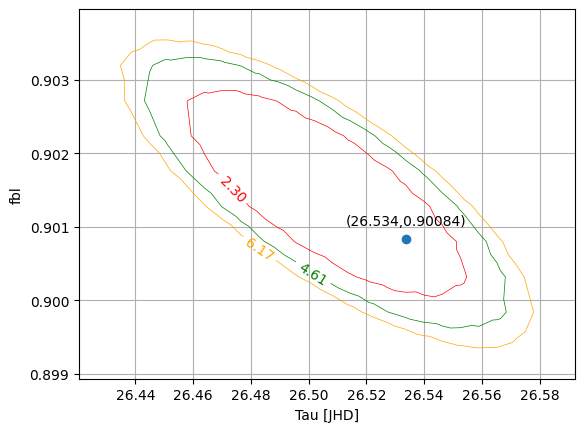

In [6]:

ms_event.non_linear_contours([T0, U_MIN, TAU, F_BL], fixed_params)

In [7]:
ms_event.non_lin_bootstrap(init_params=params_range, fixed_params=fixed_params, iter=10000)